# 7-3 데이터를 압축하는 오토인코더

본 노트북은 7-3 절 본문 [코드 7-7] ~ [코드 7-8] 과 본문이 깃허브 노트북에 미룬 학습 루프, 입력/재현 시각화([그림 7-10], [그림 7-11]) 를 포함한다.

다루는 내용
- `[코드 7-7]` MNIST 오토인코더 (다층 퍼셉트론 인코더 + 디코더)
- `[코드 7-8]` 표준화 변환 없는 데이터 변환 객체
- 오토인코더 학습 함수 (입력 = 정답) — 본문은 깃허브 노트북 참고
- MNIST 데이터 준비 (훈련/검증/평가 분리)
- 조기 종료 기반 학습 루프 + 학습 곡선
- 입력 이미지와 오토인코더로 재현한 이미지 비교 ([그림 7-10])
- 입력에 노이즈를 추가한 후 재현해 노이즈 제거 효과 확인 ([그림 7-11])

> MNIST 데이터셋은 torchvision 이 자동으로 받는 데이터이므로 깃허브 저장소 규약(§13.9)에 따라 `root='../../downloads'` 로 받는다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torch, torchvision, numpy 는 기본 의존성으로 README 에서 안내한다. 별도 설치가 필요하면 아래를 사용한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q numpy torch torchvision 

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
# import copy
# import random
# import time

# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, random_split
# from torchvision import datasets, transforms
common.set_seed()
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)
device = common.get_device()

CUDA를 사용합니다.


## [코드 7-7] MNIST 오토인코더 모델 클래스

3 개의 선형 계층으로 구성된 인코더와 3 개의 선형 계층으로 구성된 디코더로 이뤄진다. 인코더의 마지막 선형 계층 뒤에는 활성화 함수가 없고, 디코더의 마지막 선형 계층 뒤에는 시그모이드 활성화 함수가 있다.

In [4]:
###############################################################################
# 코드 7-7 - 다층 퍼셉트론 인코더와 디코더로 구성된 오토인코더
###############################################################################
import torch.nn as nn

# 입력 텐서를 인코더로 압축하고 디코더로 복원하는 오토인코더
class MNISTAutoEncoder(nn.Module):
    def __init__(self, z_size=2):
        super().__init__()
        # 3개의 선형 계층으로 구성된 인코더 (마지막 출력층 활성화 계층 없음)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),      # (784,) -> (128,)
            nn.ReLU(),
            nn.Linear(128, 64),           # (128,) -> (64,)
            nn.ReLU(),
            nn.Linear(64, z_size),        # (64,) -> (z_size,)
        )
        # 3개의 선형 계층으로 구성된 디코더
        self.decoder = nn.Sequential(
            nn.Linear(z_size, 64),        # (z_size,) -> (64,)
            nn.ReLU(),
            nn.Linear(64, 128),           # (64,) -> (128,)
            nn.ReLU(),
            nn.Linear(128, 28 * 28),      # (128,) -> (784,)
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)               # 인코더: (784,) -> (z_size,)로 압축
        return self.decoder(z)            # 디코더: (z_size,) -> (784,)로 복원

주요 설계 포인트
- **인코더/디코더의 분리 구현**: 두 묶음으로 분리해 나중에 인코더만 떼어 재사용하기 용이하다.
- **인코더 마지막 계층 뒤 활성화 없음**: 잠재 벡터가 자유롭게 학습되도록 활성화 함수로 제약을 가하지 않는다.
- **디코더 마지막 계층 뒤 시그모이드**: 입력 데이터(0~1 로 정규화된 MNIST 이미지) 와 같은 범위로 출력하기 위해 시그모이드를 사용한다. ReLU 는 양의 무한대 출력이 가능해 픽셀값에 부적절하다.

## [코드 7-8] 표준화 변환 없는 데이터 변환 객체

본문은 "이미지 변환 객체에 표준화(transforms.Normalize) 가 포함되어 있으면 시그모이드(0~1) 출력으로 음수 픽셀을 재현할 수 없다" 고 강조한다. 표준화를 제거한 데이터 변환 객체를 사용한다.

In [ ]:
###############################################################################
# 코드 7-8 - MNISTAutoEncoder 모델 학습에 사용할 데이터 변환 객체
###############################################################################
from torchvision import transforms

# 데이터 변환 객체: transforms.Normalize() 표준화 변환을 사용하지 않음
transform_chain = transforms.Compose([
    transforms.ToTensor(),                   # 이미지 픽셀값을 0~1 범위로 변환
    nn.Flatten(start_dim=0),                 # (784,) 형태로 평탄화
])

## 참고 - MNIST 데이터 준비 (훈련 50,000, 검증 10,000, 평가 10,000)

본문은 "4 장의 MNIST 숫자 분류기와 같은 코드" 로 데이터셋을 나눈다고 언급한다.

In [ ]:
# 참고 - MNIST 데이터셋과 데이터로더 (4장과 같은 구성)
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

# data_root: MNIST 데이터셋 다운로드 경로
data_root = '../../downloads'

# 데이터셋 분할 재현을 위한 고정 시드
SEED = 42

# 학습용 MNIST(60,000) 를 50,000 + 10,000 으로 분리
mnist_full = datasets.MNIST(
    root=data_root, train=True, download=True,
    transform=transform_chain,
)
test_set = datasets.MNIST(
    root=data_root, train=False, download=True,
    transform=transform_chain,
)
train_set, valid_set = random_split(
    mnist_full, [50000, 10000],
    generator=torch.Generator().manual_seed(SEED),
)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 샘플: {len(train_set):,}, '
      f'검증 샘플: {len(valid_set):,}, '
      f'평가 샘플: {len(test_set):,}')
print(f'입력 텐서 형태: {tuple(train_set[0][0].shape)}')

훈련 샘플: 50,000, 검증 샘플: 10,000, 평가 샘플: 10,000
입력 텐서 형태: (784,)


## 참고 - 오토인코더 학습 함수

본문이 깃허브 노트북에 미룬 학습 코드의 `train_epoch` 는 정답 레이블을 무시하고(입력을 정답으로 사용) 손실을 계산한다. 컨벤션 §7 의 분해 패턴(`train_epoch` / `evaluate` / `train_loop`) 으로 분해해 정의하고, 조기 종료(early stopping) 를 적용한다.

> 컨벤션 정리: 본문은 변수명을 `inputs`/`_` 로 사용한다(§3.5(C) 11장 VAE 행과 같은 자기 재구성 케이스). 노트북에서도 `inputs` 를 쓰되, 정답 = 입력이므로 손실 계산에서 `loss = criterion(outputs, inputs)` 로 사용한다.

In [ ]:
# 참고 - MNISTAutoEncoder 학습 함수 (입력을 정답으로 사용)
# 1 에포크 학습 함수, 입력을 정답으로 사용하고 가중 평균 손실을 반환
def train_epoch(model, train_loader, criterion, optimizer, device):    
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in train_loader:           # 정답 레이블은 사용하지 않음
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)              # 입력 배치 텐서로 예측
        loss = criterion(outputs, inputs)    # 입력 배치 텐서를 정답으로 사용
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 검증 또는 평가를 위해 손실을 반환하는 함수
#    학습 함수와 마찬가지로 입력을 정답으로 사용
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

In [ ]:
# 참고 - 조기 종료를 적용한 학습 루프 함수

def train(model, train_loader, valid_loader, criterion, optimizer,
               epochs, device, patience=5):
    model.to(device)
    # 표준 학습 로거 설정
    log = common.EpochLogger(
        epochs, columns=('훈련 손실', '검증 손실'),
        formats=('{:.4f}', '{:.4f}'),
    )
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_state = None
    patience_counter = 0
    
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 1 에포크 최적화
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        # 검증
        valid_loss = evaluate(model, valid_loader, criterion, device)
        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss, valid_loss)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            # detach().clone()을 사용해도 분리된 파라미터 저장 가능
            best_state = {k: v.detach().clone()
                          for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:                
                break
    if best_state is not None:
        print(f'최적 {best_epoch} 에포크 모델(검증 손실: {best_valid_loss:.4f})로 복원')
        model.load_state_dict(best_state)
    return log

## 참고 - 모델 학습 (잠재 벡터 크기 2, 학습률 0.001, patience 5)

본문은 "잠재 벡터의 크기(z_size), 학습률(learning_rate), 참을성 한계(patience) 를 각각 2, 0.001, 5 로 설정했을 때 저자의 환경에서 47 에포크에서 최저 검증 손실에 도달했다" 고 안내한다.

  epoch    훈련 손실    검증 손실     시간
  1/100       0.0662       0.0537     0:07
 10/100       0.0418       0.0418     1:17
 20/100       0.0389       0.0395     2:29
 30/100       0.0376       0.0385     3:42
 40/100       0.0367       0.0379     4:54
 50/100       0.0362       0.0375     6:08
 60/100       0.0358       0.0373     7:25
최적 56 에포크 모델(검증 손실: 0.0373)로 복원


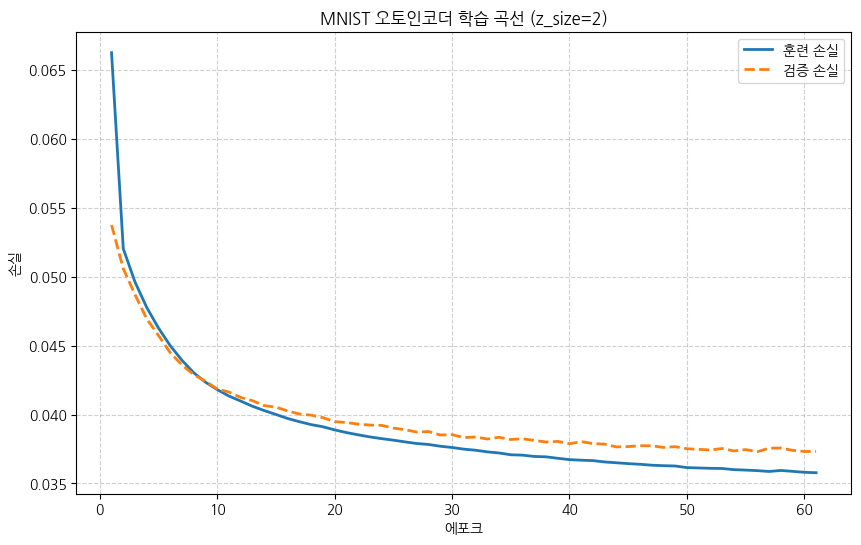

In [ ]:
# 참고 - MNISTAutoEncoder 학습
import torch.optim as optim

common.set_seed()
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

Z_SIZE = 2                  # 잠재 벡터의 크기
LR = 0.001                  # 학습률
PATIENCE = 5                # 조기 종료 인내
EPOCHS = 100                # 상한. 조기 종료로 더 일찍 끝남.

model = MNISTAutoEncoder(z_size=Z_SIZE).to(device)
criterion = nn.MSELoss()                     # 평균제곱오차 손실
optimizer = optim.Adam(model.parameters(), lr=LR)

log = train(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, device, patience=PATIENCE
)

log.plot('MNIST 오토인코더 학습 곡선 (z_size=2)')

학습 곡선은 `train_loop` 안에서 `EpochLogger.plot()` 이 자동으로 그린다(§7.7 — 학습이 있는 절은 곡선을 항상 표시). 훈련 손실과 검증 손실 두 곡선이 한 축에 함께 표시된다.


## 참고 - 오토인코더의 동작 확인 ([그림 7-10])

평가 데이터셋의 첫 8 개 샘플을 입력해 원본과 재현 이미지를 위/아래로 비교한다.

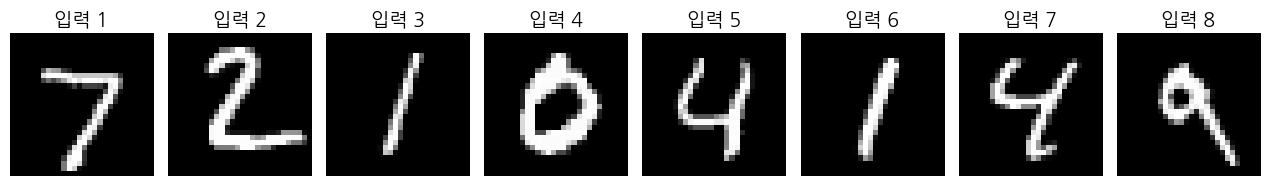

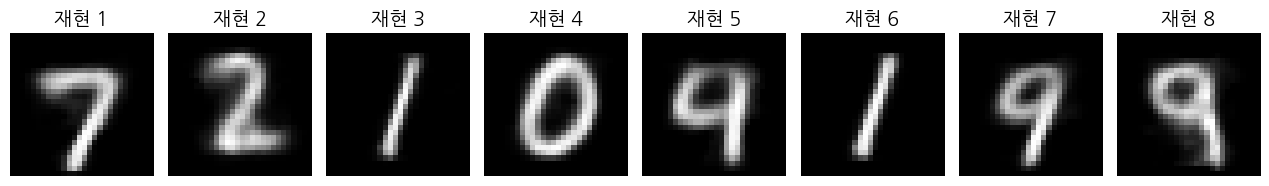

In [10]:
# 그림 7-10 - 평가 데이터셋 첫 8개 샘플과 재현 결과
model.eval()
num_show = 8
samples = [test_set[i][0] for i in range(num_show)]          # (784,) 텐서 8 개
inputs = torch.stack(samples).to(device)                     # (8, 784)
with torch.no_grad():
    outputs = model(inputs)                                  # (8, 784)

# 1D (784,) 텐서를 (28, 28) 로 복원해 viz.plot_images 로 표시
input_imgs = [s.view(28, 28) for s in samples]
output_imgs = [o.cpu().view(28, 28) for o in outputs]

descs_input = [f'입력 {i + 1}' for i in range(num_show)]
descs_output = [f'재현 {i + 1}' for i in range(num_show)]

viz.plot_images(input_imgs, descs_input, images_per_row=8)
viz.plot_images(output_imgs, descs_output, images_per_row=8)

원본과 재현 이미지를 비교하면 본문 [그림 7-10] 의 세 가지 사실을 확인할 수 있다.
- **핵심 정보 보존**: 압축률이 매우 높음에도(784 → 2) 숫자의 대략적인 모양은 살아 있다.
- **세부 정보 소실**: 가장자리의 미세한 패턴은 사라지고 뿌연 형태로 재현된다.
- **형태적 유사성에 따른 혼동**: 4 와 9, 3 과 8 처럼 모양이 비슷한 숫자 사이의 혼동이 발생한다.

## 참고 - 노이즈 추가 후 재현 ([그림 7-11])

입력 이미지에 평균 0, 표준편차 0.2 의 가우시안 노이즈를 더한 뒤 재현 결과를 확인한다.

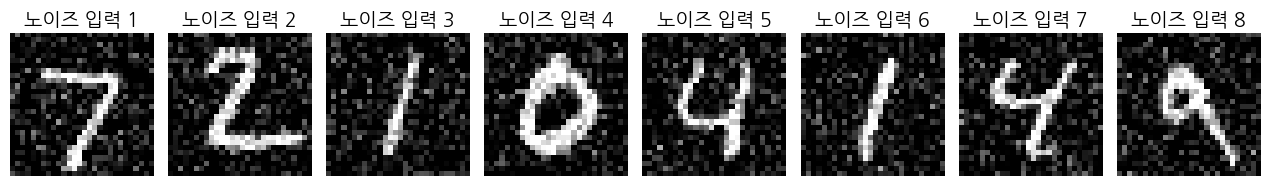

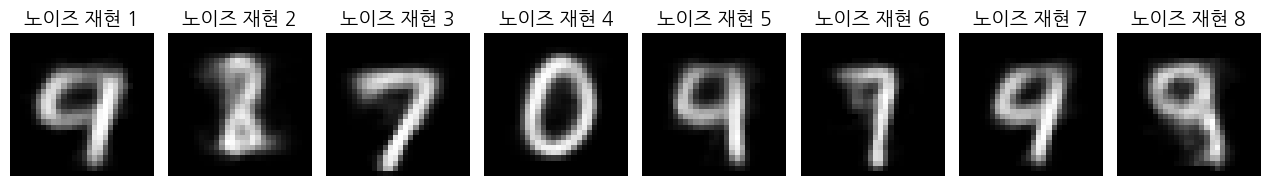

In [11]:
# 그림 7-11 - 노이즈를 추가한 입력의 재현 
torch.manual_seed(SEED)                      # 재현성을 위해 시드 고정
noise = torch.randn_like(inputs) * 0.2
noisy_inputs = (inputs + noise).clamp(0.0, 1.0)              # 픽셀 범위 유지

with torch.no_grad():
    noisy_outputs = model(noisy_inputs)

noisy_input_imgs = [n.cpu().view(28, 28) for n in noisy_inputs]
noisy_output_imgs = [o.cpu().view(28, 28) for o in noisy_outputs]

descs_noisy_in = [f'노이즈 입력 {i + 1}' for i in range(num_show)]
descs_noisy_out = [f'노이즈 재현 {i + 1}' for i in range(num_show)]

viz.plot_images(noisy_input_imgs, descs_noisy_in, images_per_row=8)
viz.plot_images(noisy_output_imgs, descs_noisy_out, images_per_row=8)

노이즈를 추가한 입력에서도 재현 이미지에는 노이즈가 거의 보이지 않는다. 다만 본문 설명대로 잠재 벡터 크기가 2 로 매우 작아 노이즈 때문에 핵심 정보가 흐트러져 본래와 다른 숫자로 재현되는 부작용도 보인다.

## 정리

- MNIST 오토인코더는 다층 퍼셉트론 인코더와 디코더로 구성되며, 입력과 정답이 같은 자기 지도 학습 방식으로 학습된다.
- 출력층 활성화 함수는 입력 데이터의 값 범위(0~1 정규화된 픽셀) 에 맞춰 시그모이드를 선택한다. 표준화 변환(transforms.Normalize) 을 제거한 데이터 변환 객체를 사용해야 한다.
- 손실 함수는 픽셀 단위의 차이를 측정하는 평균제곱오차(`nn.MSELoss`) 를 사용한다.
- 잠재 벡터 크기 2 의 매우 작은 잠재 공간으로 압축한 후 복원하면 핵심 정보는 보존되지만 세부 정보는 손실된다. 노이즈 입력에 대해서도 노이즈 제거 효과가 나타난다.